In [137]:
import os
import zipfile
import pandas as pd
from tqdm.notebook import tqdm  
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
#Setting up paths for data files
MAIN_ZIP_PATH = "tennis_data.zip"
EXTRACT_DIR = "extracted_data"


In [3]:
#Unzip the main data file
with zipfile.ZipFile(MAIN_ZIP_PATH, 'r') as main_zip:
    main_zip.extractall(EXTRACT_DIR)
print("Outer zip extracted.")


Outer zip extracted.


In [7]:
#Unzip the inner zips
for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        if file.endswith('.zip'):
            zip_path = os.path.join(root, file)
            extract_subdir = os.path.join(root, file.replace('.zip', ''))
            os.makedirs(extract_subdir, exist_ok=True)

            try:
                with zipfile.ZipFile(zip_path, 'r') as nested_zip:
                    nested_zip.extractall(extract_subdir)
            except:
                print("Not a Zip")
print("Nested zips extracted.")


Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Not a Zip
Nested zips extracted.


In [ ]:
#Load parquet files

parquet_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        if file.endswith('.parquet'):
            parquet_files.append(os.path.join(root, file))

print(f"Found {len(parquet_files)} parquet files.")

# Now load dfs
dfs = []
for fp in tqdm(parquet_files, desc="Loading Parquet files"):
    try:
        dfs.append(pd.read_parquet(fp))
    except Exception as e:
        print(f"Failed to read {fp}: {e}")

df = pd.concat(dfs, ignore_index=True)
 

Found 442812 parquet files.


Loading Parquet files:   0%|          | 0/442812 [00:00<?, ?it/s]

C:\Users\Adnan\AppData\Local\Temp\ipykernel_13104\199295892.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


In [ ]:
df.to_csv("all_matches.csv", index=False)
df.head()


,match_id,name,slug,gender,user_count,residence,birthplace,height,weight,plays,...,home_value,away_value,home_total,away_total,set_num,game_num,value,break_occurred,home_vote,away_vote
0,11998445,Auger-Aliassime F.,auger-aliassime-felix,M,23318.0,"Monte Carlo, Monaco","Montreal, Canada",1.93,87.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11998446,Cobolli F.,flavio-cobolli,M,5995.0,Rome,"Florence, Italy",1.83,71.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11998447,Martínez P.,martinez-pedro,M,2621.0,"Valencia, Spain","Alzira, Spain",1.85,76.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11998448,Muller A.,muller-alexandre,M,2443.0,France,"Poissy, France",1.83,73.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11998449,Mayot H.,mayot-harold,M,1492.0,"Marly, France","Metz, France",1.78,78.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
#For later uses of the code, data is already loaded in the address below,
#  so there is no need to reed and load all the parquet files:
df = pd.read_csv("all_matches.csv") 

C:\Users\Adnan\AppData\Local\Temp\ipykernel_13104\1426639595.py:3: DtypeWarning: Columns (1,2,3,5,6,9,15,16,17,32,33,34,38,39,46,47,49,50,51,53,54,55,56,59,60,63,64,65,66,67,68,70,75,76,84,85,86,87,88,90,91,99) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("all_matches.csv")


In [87]:
df.shape  # Number of rows and columns


(4790686, 102)

In [88]:
df.columns  # See available columns


Index(['match_id', 'name', 'slug', 'gender', 'user_count', 'residence',
       'birthplace', 'height', 'weight', 'plays',
       ...
       'home_value', 'away_value', 'home_total', 'away_total', 'set_num',
       'game_num', 'value', 'break_occurred', 'home_vote', 'away_vote'],
      dtype='object', length=102)

In [89]:
df.sample(5)  # Peek at random rows to understand column content


,match_id,name,slug,gender,user_count,residence,birthplace,height,weight,plays,...,home_value,away_value,home_total,away_total,set_num,game_num,value,break_occurred,home_vote,away_vote
3607211,12163803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4125509,12178450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,2.0,-26.82,False,NaN,NaN
1341675,12082596,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3680817,12166342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2251532,12088016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
#df.drop_duplicates()

In [ ]:
# Group by match_id and keep the first non-null value per column
'''df_cleaned = df.groupby('match_id').agg(lambda x: x.dropna().iloc[0] if not x.dropna().empty else None).reset_index()
df = df_cleaned'''
#Ruined the data, that's why it's commented

"df_cleaned = df.groupby('match_id').agg(lambda x: x.dropna().iloc[0] if not x.dropna().empty else None).reset_index()\ndf = df_cleaned"

Question #4

In [93]:
# Ensure all period columns exist
period_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']

# Handle missing values (e.g., null sets in short matches)
for col in period_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Add total match time column
df['total_match_time'] = df[period_cols].sum(axis=1)


In [94]:
# Get the match with the maximum total time
longest_match = df[df['total_match_time'] == df['total_match_time'].max()]
longest_match


,match_id,name,slug,gender,user_count,residence,birthplace,height,weight,plays,...,away_value,home_total,away_total,set_num,game_num,value,break_occurred,home_vote,away_vote,total_match_time
762017,12063611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,336790.0
835226,12063611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,336790.0
930431,12063611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,336790.0
1034959,12063611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,336790.0


In [95]:
# Period columns (individual set durations)
period_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']

# Row with the longest match
longest_match = df[df['total_match_time'] == df['total_match_time'].max()]

# Show set durations
longest_match[period_cols]


,period_1,period_2,period_3,period_4,period_5
762017,167352.0,169438.0,0.0,0.0,0.0
835226,167352.0,169438.0,0.0,0.0,0.0
930431,167352.0,169438.0,0.0,0.0,0.0
1034959,167352.0,169438.0,0.0,0.0,0.0


In [ ]:
# Extract MatchTimeInfo
time_cols = ['match_id', 'period_1', 'period_2', 'period_3', 'period_4', 'period_5']
match_time_df = df[time_cols].dropna(subset=['period_1'])  # Drop empty rows

# Ensure numeric
for col in time_cols[1:]:
    match_time_df[col] = pd.to_numeric(match_time_df[col], errors='coerce').fillna(0)

# Compute total duration
match_time_df['total_match_time'] = match_time_df.iloc[:, 1:].sum(axis=1)

# Find the longest match
longest_match = match_time_df.sort_values('total_match_time', ascending=False).head(1)
longest_match


,match_id,period_1,period_2,period_3,period_4,period_5,total_match_time
1034959,12063611,167352.0,169438.0,0.0,0.0,0.0,336790.0


Judging by this number, we can say with absolute certainty that it is in tenth of seconds, so we can say that the longest match in this data set lasted for 9 hours, 21 minutes and 19 seconds.

Question #6

It's very difficult to extract an accurate metric for success of a country, so the metric that has been chosen here is the amount of prize that has been won by each country.

In [ ]:

# Step 1: Extract prize money info
home_prize = df[['player_id', 'country', 'total_prize']].dropna()
away_prize = df[['player_id', 'country', 'total_prize']].dropna()

prize_df = pd.concat([home_prize, away_prize], ignore_index=True)
prize_df = prize_df.drop_duplicates(subset='player_id')  # Avoid duplicate players

# Step 2: Sum prize money per country
country_prize = prize_df.groupby('country')['total_prize'].sum().reset_index()
country_prize = country_prize.sort_values('total_prize', ascending=False)


C:\Users\Adnan\AppData\Local\Temp\ipykernel_13104\2784999938.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_prize.head(10), x='total_prize', y='country', palette='Greens_d')


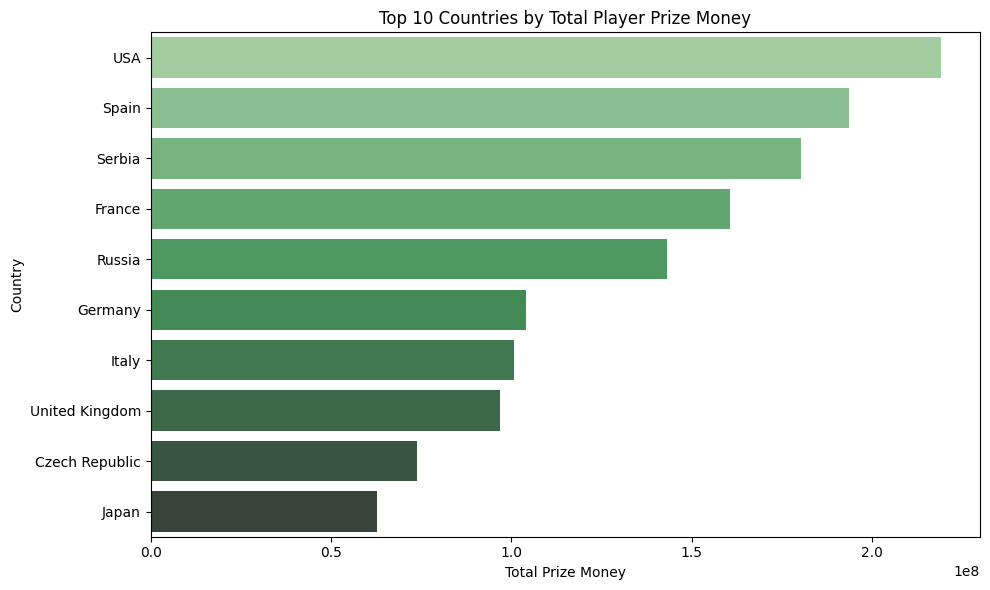

In [139]:
plt.figure(figsize=(10, 6))
sns.barplot(data=country_prize.head(10), x='total_prize', y='country', palette='Greens_d')
plt.title("Top 10 Countries by Total Player Prize Money")
plt.xlabel("Total Prize Money")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


Question #11

We can use the total_match_time column that we produced ourselves to easily calculate the average time for each match.
It can be seen that the average amount is way too short, and this is probably because of faulty data, a lot of periods have times like 4 or 6 which is not easily recognized as null data, but might as well be.

In [212]:
# Drop missing values
duration_series = df['total_match_time'].dropna()

# Only keeping positive durations
positive_durations = duration_series[duration_series > 0]

# Compute average and convert to seconds
average_duration = positive_durations.mean() / 10

print(f"Average match duration: {average_duration:.2f} seconds")


Average match duration: 188.17 seconds
